# Annnotation, Subclustering, Trajectory

## Loading in Data

In [2]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import seaborn as sns

In [4]:
data_dir = "."
output_dir = "output"
figure_dir = "output/figures"

# sc.settings.figdir = output_dir
# sc.settings.set_figure_params(dpi=150, facecolor="white", figsize=(10, 7))
from matplotlib import colors as mplc
_colors = ["lightgray", "royalblue", "gold"]
cmap = mplc.LinearSegmentedColormap.from_list("gray_blue_yellow", _colors)

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

In [9]:
input_file = os.path.join(data_dir, "pp_and_umap_data.h5ad")
adata = ad.read_h5ad(input_file)

In [10]:
treatment_groups = adata.obs["sample"].unique()
treatment_groups

['PBMC_Control1', 'PBMC_Control2', 'Lung_Cancer_PBMC']
Categories (3, object): ['PBMC_Control1', 'PBMC_Control2', 'Lung_Cancer_PBMC']

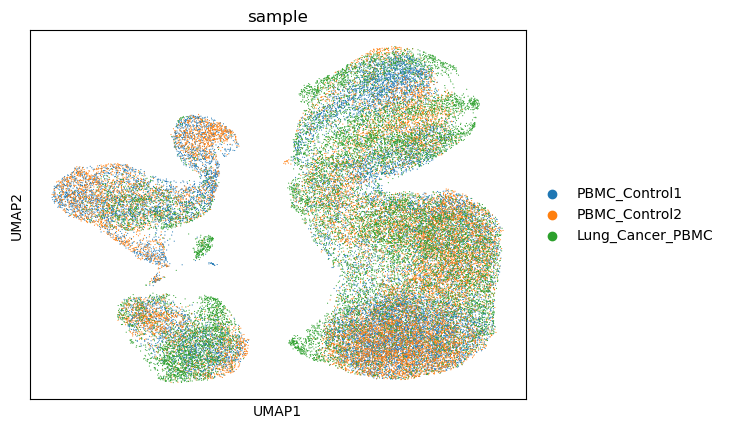

In [11]:
sc.pl.umap(adata, color="sample")

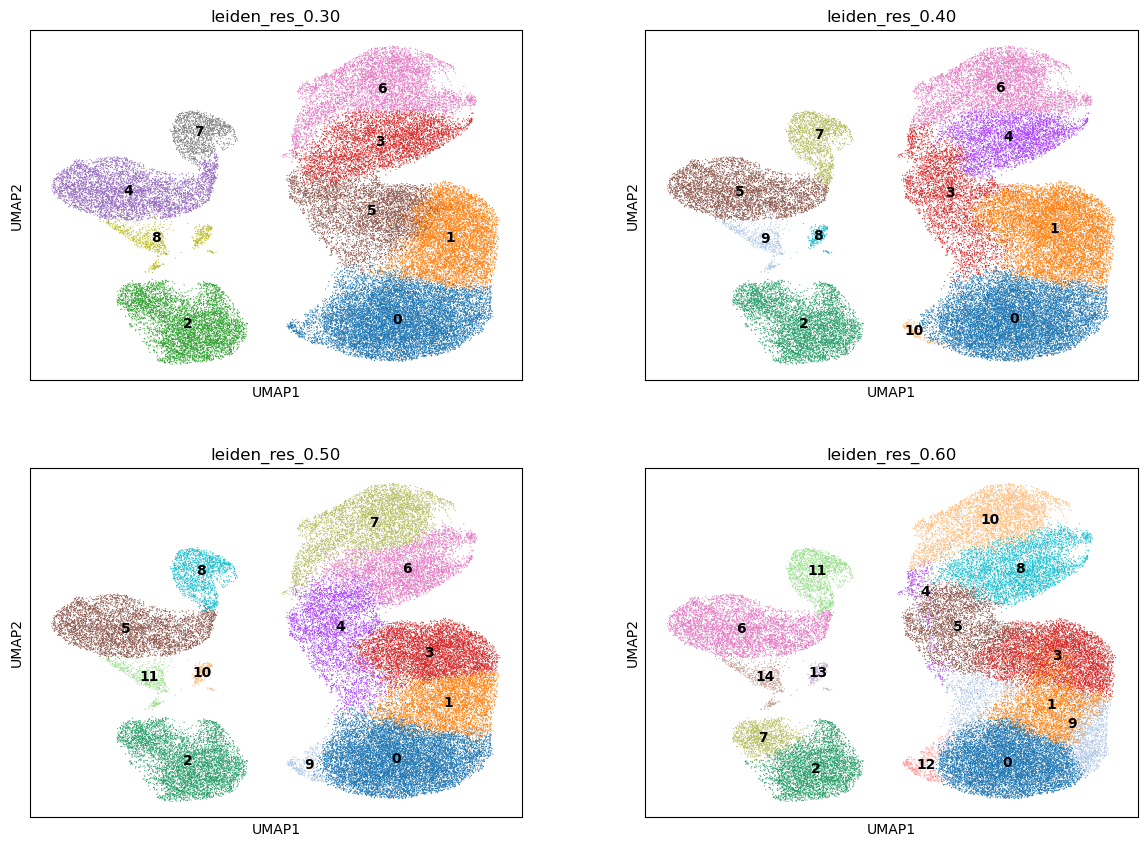

In [13]:
# Drop old leiden cols
cols_to_drop = [col for col in adata.obs.columns if col.startswith("leiden_")]
adata.obs.drop(columns=cols_to_drop, inplace=True)

resolutions = [0.3, 0.4, 0.5, 0.6]
for res in resolutions:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

sc.pl.umap(
    adata,
    color=[f"leiden_res_{res:4.2f}" for res in resolutions],
    legend_loc="on data",
    ncols = 2
)

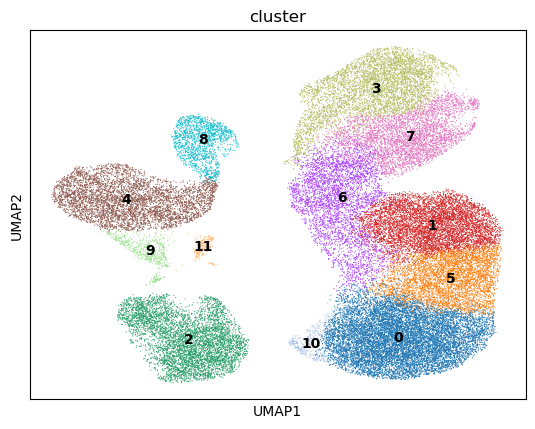

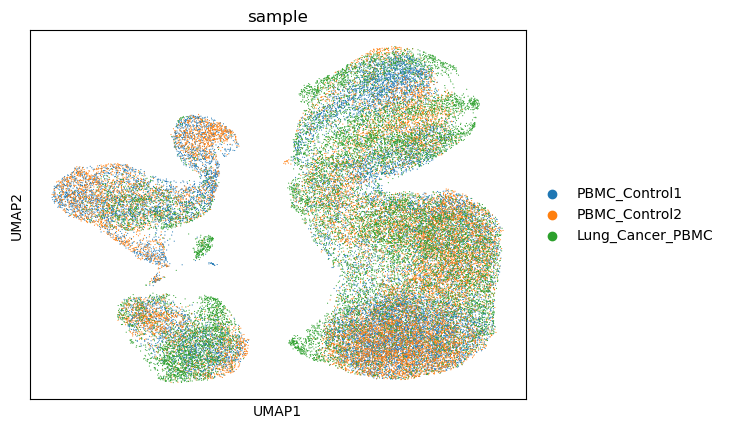

In [15]:
_resolution = "leiden_res_0.50"
# rename clusters in order of size
cluster_sizes = adata.obs[_resolution].value_counts().sort_values(ascending=False)
new_labels = {cluster: str(idx) for idx, cluster in enumerate(cluster_sizes.index)}
adata.obs["cluster"] = adata.obs[_resolution].map(new_labels)
adata.uns["cluster_colors"] = adata.uns[_resolution + "_colors"]
cluster_sizes.index = cluster_sizes.index.map(new_labels)
n_clusters = len(cluster_sizes)
sc.pl.umap(adata, color="cluster", legend_loc="on data")
sc.pl.umap(adata, color="sample")

In [ ]:
df = (
    adata.obs.groupby(["cluster", "sample"]).size()
    .reset_index().pivot(index="cluster", columns="sample", values=0)
    .fillna(0).astype(int)
    .assign(Total=lambda x: x.sum(axis=1))
)
df.index = df.index.astype(int)
df.sort_index()
df

sample   PBMC_Control1  PBMC_Control2  Lung_Cancer_PBMC  Total
cluster                                                       
0                 5497           4108              1497  11102
5                 1262           1832              1359   4453
2                 1747           1397              2202   5346
1                 1769           2289              2034   6092
6                 1219           1232              1697   4148
4                 2355           1619               769   4743
7                  885           1064              2141   4090
3                 2183            886              1691   4760
8                  827            730                59   1616
10                   7             20               363    390
11                  32              6               206    244
9                  316            252                12    580


/var/folders/2s/_00dd2vx0blcvkt9x4m4l1th0000gn/T/ipykernel_8987/2792503290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["cluster", "sample"]).size()


## Annotation

In [24]:
sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon")

In [25]:
def get_expression_by_obs(anndata, column):
    sc.tl.rank_genes_groups(anndata, groupby=column, method="wilcoxon")
    df = sc.get.rank_genes_groups_df(anndata, group=None)
    df.rename(columns={"group": column}, inplace=True)
    df_pct_expr = []
    for c in df[column].unique():
        subset = anndata[anndata.obs[column] == c]
        percent_expressing = ((subset.layers["counts"] > 0).sum(axis=0) / len(subset)).A1 * 100
        average_expression = subset.X.mean(axis=0).A1
        df_pct_expr.append(pd.DataFrame({
            column: c,
            "names": subset.var_names, 
            "percent_expressing": percent_expressing,
            "average_expression": average_expression,
        }).set_index([column, "names"]))
        
    df = df.join(pd.concat(df_pct_expr), on=[column, "names"], how="left")
    if pd.to_numeric(df[column], errors="coerce").notna().all():
        df = df.astype({column: int})
    return df.sort_values([column, "scores"], ascending=[True, False])

ebc = get_expression_by_obs(adata, "cluster")
ebc["cluster"] = ebc["cluster"].astype(int)
adata.uns["expression_by_cluster"] = ebc
ebc

,cluster,names,scores,logfoldchanges,pvals,pvals_adj,percent_expressing,average_expression
0,0,TCF7,131.006973,3.101085,0.000000e+00,0.000000e+00,98.450730,2.506712
1,0,LEF1,129.205658,3.468024,0.000000e+00,0.000000e+00,93.235453,1.676490
2,0,CCR7,116.903328,3.351396,0.000000e+00,0.000000e+00,85.552153,1.327166
3,0,SATB1,115.930740,2.343743,0.000000e+00,0.000000e+00,94.253288,1.821572
4,0,DGKA,111.116989,2.178932,0.000000e+00,0.000000e+00,95.829580,1.728129
...,...,...,...,...,...,...,...,...
172090,11,EEF2,-23.767378,-4.220744,7.265653e-125,1.136711e-121,19.262295,0.331814
172091,11,ARHGDIB,-23.819555,-4.422374,2.094819e-125,3.641493e-122,14.344262,0.229571
172092,11,EVL,-23.910366,-5.741467,2.389478e-126,6.230563e-123,6.147541,0.102163
172093,11,TMSB10,-24.380953,-4.244474,2.723531e-131,8.521929e-128,21.721311,0.358416


In [36]:
import celltypist as ct
import celltypist.models as ctm
ctm.download_models()
print(ctm.models_description())

📂 Storing models in /Users/nirreiter/.celltypist/data/models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/61]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/61]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/61]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipping [16/61]: Autopsy_COVID19_Lung.pk

                                      model  \
0                        Immune_All_Low.pkl   
1                       Immune_All_High.pkl   
2                    Adult_COVID19_PBMC.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                       Adult_Human_MTG.pkl   
..                                      ...   
56                   Nuclei_Lung_Airway.pkl   
57       PaediatricAdult_COVID19_Airway.pkl   
58         PaediatricAdult_COVID19_PBMC.pkl   
59                      Pan_Fetal_Human.pkl   
60                Thymus_Allograft_PBMC.pkl   

                                          description  
0   immune sub-populations combined from 20 tissue...  
1   immune populations combined from 20 tissues of...  
2   peripheral blood mononuclear cell types from C...  
3   cell types from the hippocampus of adult cynom...  
4   cell types and subtypes (10x-based) from the a...  
..                                                ...  
56  cell populations from snRNA-seq of five

In [39]:
type_model = ctm.Model.load(model = "Immune_All_Low.pkl")
display(type_model)
display(type_model.cell_types)

/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 0.24.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 0.24.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


CellTypist model with 98 cell types and 6639 features
    date: 2022-07-16 00:20:42.927778
    details: immune sub-populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: Age-associated B cells, Alveolar macrophages, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells', 'CD8a/a', 'CD8a/b(entry)',
       'CMP', 'CRTAM+ gamma-delta T cells', 'Classical monocytes',
       'Cycling B cells', 'Cycling DCs', 'Cycling NK cells',
       'Cycling T cells', 'Cycling gamma-delta T cells',
       'Cycling monocytes', 'DC', 'DC precursor', 'DC1', 'DC2', 'DC3',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ELP',
       'ETP', 'Early MK', 'Early erythroid', 'Early lymphoid/T lymphoid',
       'Endothelial cells', 'Epithelial cells', 'Erythrocytes',
       'Erythrophagocytic macrophages', 'Fibroblasts',
       'Follicular B cells', 'Follicular helper T cells', 'GMP',
       'Germinal center B cells', 'Granulocytes', 'HSC/MPP',
       'Hofbauer cells', 'ILC', 'ILC precursor', 'ILC1', 'ILC2', 'ILC3',
       'Intermediate macrophages', 'Intestinal macrophages',
       'Kidney-resident macrophages', 'Kupffer cells',
       'Large pre-B cell

In [56]:
from scipy import sparse
x: sparse.csr_matrix = adata.layers["counts"]
x.dtype

dtype('float64')

In [67]:
_adata = adata.copy()
_adata.X = _adata.layers["counts"]
sc.pp.normalize_total(_adata, target_sum=10_000)
sc.pp.log1p(_adata)
predictions = ct.annotate(_adata, model = "Immune_All_Low.pkl", majority_voting = True, mode = "prob match")
adata_predictions = predictions.to_adata()

/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 0.24.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 0.24.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
🔬 Input data has 47564 cells and 15645 genes
🔗 Matching reference genes in the model
🧬 4878 features used for prediction
⚖️ Scaling input da

/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.12/site-packages/anndata/_core/anndata.py:812: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['Age-associated B cells', 'CD16+ NK cells', 'Classical monocytes', 'DC2', 'Memory B cells']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "obs")


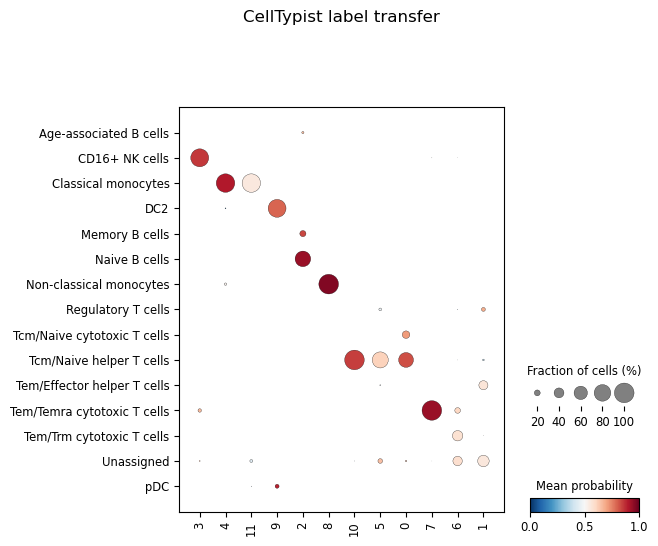

In [68]:
ct.dotplot(predictions, use_as_reference = "cluster", use_as_prediction = "majority_voting")

In [58]:
# ct.plot._get_fraction_prob_df(predictions_low, use_as_reference = "cluster", use_as_prediction = "majority_voting")

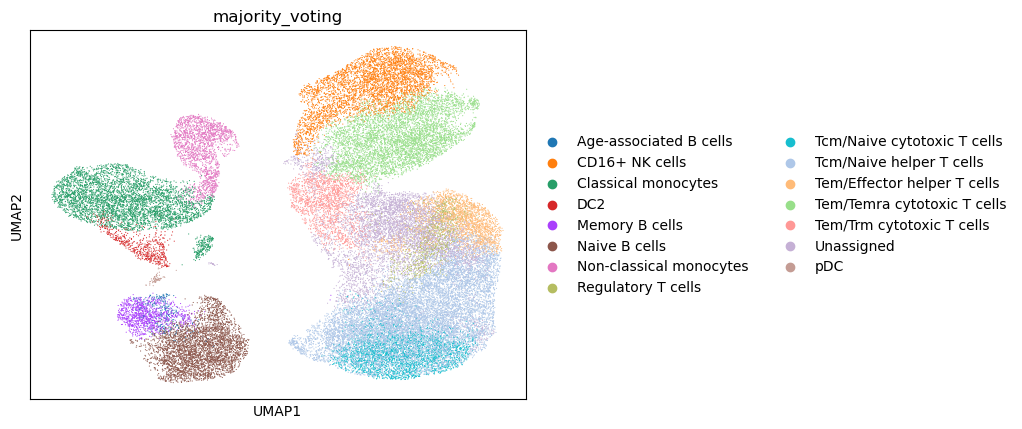

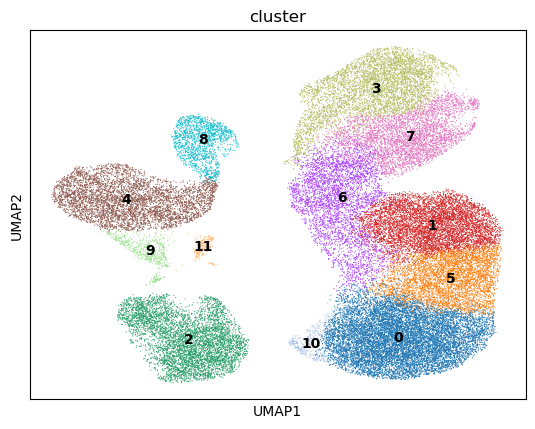

In [72]:
sc.pl.umap(adata_predictions, color="majority_voting")
sc.pl.umap(adata_predictions, color="cluster", legend_loc="on data")

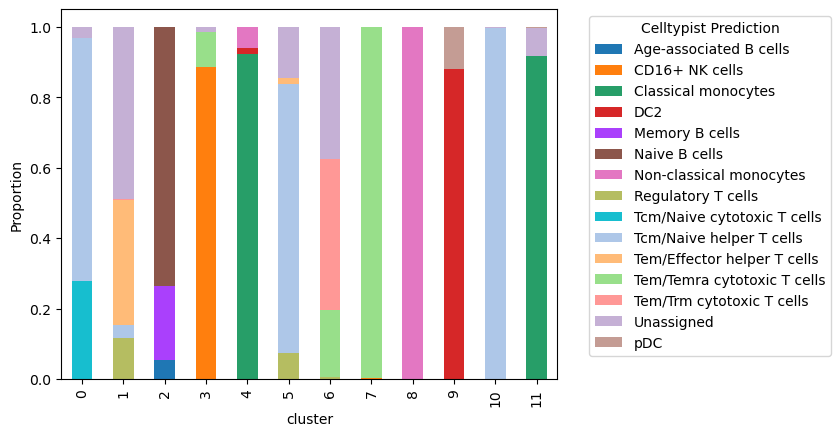

In [81]:
counts = pd.crosstab(adata_predictions.obs['cluster'], adata_predictions.obs['majority_voting'], normalize='index')
counts.index = counts.index.astype(int)
counts = counts.sort_index()
counts.plot(kind='bar', stacked=True, color=adata_predictions.uns["majority_voting_colors"])
plt.ylabel('Proportion')
plt.legend(title='Celltypist Prediction', bbox_to_anchor=(1.05, 1), loc='upper left')

In [75]:
# sns.violinplot(x=adata.obs["majority_voting"], y=adata.raw[:, "IGHD"].X.toarray().flatten(), density_norm="width")

In [76]:
# top_3 = type_model.extract_top_markers("Naive B cells", 3)
# print(top_3)
# sc.pl.violin(adata, top_3, groupby="majority_voting", rotation=90)

In [ ]:
celltypist_prediction = counts.apply(
    lambda r: ", ".join(
        f"{col} ({val*100:.1f}%)" 
        for col, val in sorted(r.items(), key=lambda x: -x[1]) 
        if val > 0
    ), 
    axis=1,
)

annotation = pd.DataFrame(columns=[
    "cell count",
    "top 30 genes",
    "celltypist guess",
])
for i in range(n_clusters):
    annotation.loc[i] = [
        cluster_sizes[str(i)], 
        ", ".join(ebc[ebc.cluster == i].names.head(30)),
        celltypist_prediction.loc[i],
    ]
annotation.to_excel(os.path.join(output_dir, "annotation_guess.xlsx"), index_label="cluster")
annotation

,cell count,top 30 genes,celltypist guess
0,11102,"TCF7, LEF1, CCR7, SATB1, DGKA, TRABD2A, OXNAD1...","Tcm/Naive helper T cells (68.9%), Tcm/Naive cy..."
1,6092,"IL32, IL7R, S100A10, AHNAK, B2M, SPOCK2, PRDM1...","Unassigned (48.9%), Tem/Effector helper T cell..."
2,5346,"MS4A1, CD79A, CD37, TNFRSF13C, CD74, NIBAN3, C...","Naive B cells (73.5%), Memory B cells (21.2%),..."
3,4760,"GNLY, IL2RB, NKG7, CTSW, KLRD1, PRF1, EFHD2, K...","CD16+ NK cells (88.7%), Tem/Temra cytotoxic T ..."
4,4743,"LYZ, S100A9, S100A8, GRN, CSF3R, CD14, TNFAIP2...","Classical monocytes (92.3%), Non-classical mon..."
5,4453,"IL7R, LDHB, LTB, TCF7, MAL, FXYD5, DGKA, RCAN3...","Tcm/Naive helper T cells (76.5%), Unassigned (..."
6,4148,"CCL5, DUSP2, GZMK, KLRG1, CST7, NKG7, SYNE2, C...","Tem/Trm cytotoxic T cells (42.9%), Unassigned ..."
7,4090,"GZMH, CCL5, NKG7, GNLY, CST7, ADGRG1, SYNE1, F...","Tem/Temra cytotoxic T cells (99.7%), CD16+ NK ..."
8,1616,"LST1, CSF1R, LRRC25, AIF1, SERPINA1, COTL1, MS...",Non-classical monocytes (100.0%)
9,580,"CST3, CD74, CTSZ, GSN, SAMHD1, KCTD12, GRN, JA...","DC2 (88.1%), pDC (11.9%)"


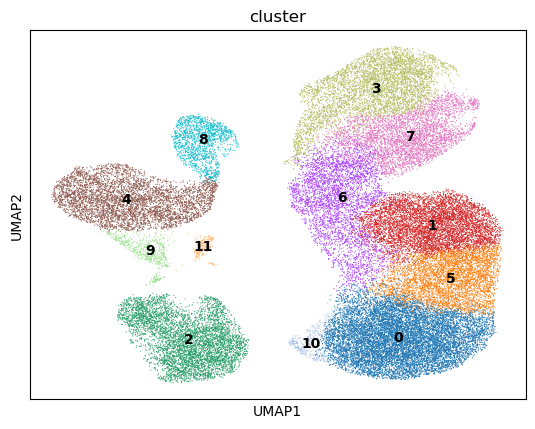

In [70]:
sc.pl.umap(adata, color=["cluster"], cmap=cmap, legend_loc="on data")

## Manual Search

In [ ]:
# Useful in troubleshooting
def print_genes_startswith(name: str):
    genes = [g for g in adata.var_names if g.startswith(name)]
    print("\n".join(sorted(genes)))

In [105]:
all_genes = set(adata.var_names)
def check_expr(features, score_threshold, clusters=None):
    if isinstance(features, str):
        features = [features]
    e = adata.uns["expression_by_cluster"]
    for gene in features:
        if gene not in all_genes:
            print("Gene not present:", gene)
    
    if clusters is not None:
        e = e.loc[e.cluster.isin(clusters)]
        str_clusters = [str(c) for c in clusters]
        subset = adata[adata.obs["cluster"].isin(str_clusters)]
    else:
        subset = adata
    
    print(e.loc[e.names.isin(features)]
        .loc[(e.scores > score_threshold)]
        .sort_values(["cluster", "scores"], ascending=False)
        .loc[:, ["cluster", "names", "scores", "percent_expressing", "average_expression"]])
    sc.pl.umap(
        subset, 
        color=["cluster"] + features, 
        cmap=cmap,
        ncols=3,
        legend_loc="on data",
        vmin=0,
    )

In [ ]:
def umap_by_treatment(adata, feature, **kwargs):
    sc.set_figure_params(scanpy=True, dpi=300)

    if feature == "annotation":
        # Get annotation categories and colors
        categories = adata.obs["annotation"].cat.categories
        colors = adata.uns["annotation_colors"]
        color_dict = dict(zip(categories, colors))
        # Create legend handles
        handles = [
            plt.Line2D([], [], marker='o', linestyle='None', color=color_dict[cat],
                       label=cat, markersize=6, )
            for cat in categories
        ]
    
    # Create figure with 2x2 plots and a separate column for the legend
    fig = plt.figure(figsize=(14, 10))  # wider to make room for legend
    gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.4])  # right column for legend
    
    # Create 4 UMAP plots
    axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]
    
    for i, t in enumerate(treatment_groups):
        sc.pl.umap(
            adata[adata.obs["sample"] == t],
            color=feature,
            ax=axes[i],
            show=False,
            size=7,
            legend_loc=None,  # no legend
            title=t,
            **kwargs
        )
    
    # Custom legend in the rightmost column
    legend_ax = fig.add_subplot(gs[:, 2])  # full height of right column
    legend_ax.axis("off")  # no frame

    if feature == "annotation":
        # Draw the legend
        legend_ax.legend(
            handles=handles,
            loc='center left',
            frameon=False,
            title=feature,
            fontsize=15,
            title_fontsize=18
        )
    
    plt.tight_layout()
    # plt.subplots_adjust(wspace=0.3)  # more space between plots and legend
    plt.show()

## Subclustering

### Helper Functions

In [ ]:
def get_subcluster_top_genes(anndata, key="cluster"):
    sc.tl.rank_genes_groups(anndata, groupby=key, method="wilcoxon")
    df = sc.get.rank_genes_groups_df(anndata, group=None)
    df = df.rename(columns={"group": key})
    df_pct_expr = []
    for c in df[key].unique():
        subset = anndata[anndata.obs[key] == str(c)]
        percent_expressing = ((subset.layers["counts"] > 0).sum(axis=0) / len(subset)).A1 * 100
        average_expression = subset.X.mean(axis=0).A1
        df_pct_expr.append(pd.DataFrame({
            key: c,
            "names": subset.var_names, 
            "percent_expressing": percent_expressing,
            "average_expression": average_expression,
        }).set_index([key, "names"]))
        
    df = df.join(pd.concat(df_pct_expr), on=[key, "names"], how="left")
    df = df.astype({key: int})
    return df

In [ ]:
def score_cell_types(ebc, cell_types: dict, key="cluster"):
    all_features = set(ebc.names.unique())
    df_scores = pd.DataFrame()
    for c, features in cell_types.items():
        positive_features = []
        negative_features = []
        for f in features:
            if f[-1] == '-':
                if f[:-1] not in all_features:
                    print(f"WARNING: {f[:-1]} not in dataset!")
                else:
                    negative_features.append(f[:-1])
            else:
                if f not in all_features:
                    print(f"WARNING: {f} not in dataset!")
                else:
                    positive_features.append(f)
        
        positive = ebc[ebc.names.isin(positive_features)].groupby(key).scores.sum()
        negative = ebc[ebc.names.isin(negative_features)].groupby(key).scores.sum()
        if len(positive) == 0:
            score = -negative / len(negative)
        elif len(negative) == 0:
            score = positive / len(positive)
        else:
            score = (positive - negative) / (len(positive) + len(negative))
        df_scores[c] = score
    return df_scores

In [ ]:
# returns (total_count, dict of group counts)
def get_count_expressing(adata, groups, gene, threshold=0.01):
    found_in_both = False
    if gene in adata.var_names and gene in adata.obs.columns:
        print(f"WARNING: {gene} found in both gene names and observations. You may have created an observation with the same name as one of your genes. Avoid doing this to prevent confusion.")

    if groups is not None:
        group_counts = {k: len(g) for k, g in groups.items()}
    total_count = len(adata)

    result = {}

    if gene in adata.var_names:
        count = np.count_nonzero(adata[:, gene].X > threshold)
        if groups is not None:
            group_expression = {k: np.count_nonzero(g[:, gene].X > threshold) for k, g in groups.items()}
            return count, group_expression
        return count, None
    elif gene in adata.obs.columns:
        count = np.count_nonzero(adata.obs[gene] > threshold)
        if groups is not None:
            group_expression = {k: np.count_nonzero(g.obs[gene] > threshold) for k, g in groups.items()}
            return count, group_expression
        return count, None
    else:
        return 0, {}

In [ ]:
def format_count_expressing(gene, count, count_expressing):
    if not isinstance(gene, list):
        gene = [gene]
    if not isinstance(count_expressing, list):
        count_expressing = [count_expressing]
    if not isinstance(count, list):
        count = [count]

    l = max(len(g) for g in gene)
    return "\n".join([
        f"{g.ljust(l)} - {e:4d} / {c} ({e/c*100:0.1f}%) expressing" 
        for g, e, c in zip(gene, count_expressing, count)
    ])

In [ ]:
colors = ["red", "lightgray", "blue"]
newcmap = mpl.colors.LinearSegmentedColormap.from_list("RedGrayBlue", colors, N=256)

def umap_cmap_centered(adata, obs, **kwargs):
    sc.set_figure_params(scanpy=True, fontsize=16, figsize=(8,8))
    # Center color scale at zero
    absmax = []
    if isinstance(obs, str):
        obs = [obs]
    for o in obs:
        vmin = adata.obs[o].min()
        vmax = adata.obs[o].max()
        absmax.append(max(abs(vmin), abs(vmax)))
    absmax = max(absmax)
    
    # Plot UMAP with custom colormap
    sc.pl.umap(adata, color=obs, cmap=newcmap, vmin=-absmax, vmax=absmax, **kwargs)


def imshow_cmap_centered(data: pd.DataFrame, vlimit=None):
    absmax = abs(vlimit) if (vlimit is not None) else max(
        abs(data.min().min()), 
        abs(data.max().max())
    )
    
    plt.imshow(data, cmap=newcmap, vmin=-absmax, vmax=absmax)
    plt.grid(False)
    plt.yticks(range(len(data.index)), data.index)
    plt.xticks(range(len(data.columns)), data.columns)
    for c in data.columns:
        if len(str(c)) > 8:
            plt.xticks(rotation=90)
            break
    plt.colorbar()

### B cells

In [ ]:
b_cells = adata[adata.obs["cluster"].isin(["2"])].copy()
sc.tl.pca(b_cells, svd_solver="arpack", random_state=SEED)
sc.pl.pca_variance_ratio(b_cells, n_pcs=40, log=True)
sc.pl.pca(
    b_cells,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=10,
)
sc.pp.neighbors(b_cells, n_neighbors=10, n_pcs=20, method='umap', metric='euclidean', random_state=SEED)
sc.tl.umap(b_cells, min_dist=0.01, spread=1.0, random_state=SEED)

In [ ]:
_resolutions = [0.3, 0.35, 0.4, 0.5]
for resolution in _resolutions:
    sc.tl.leiden(b_cells, key_added=f"subcluster_{resolution}", resolution=resolution, flavor="igraph")
sc.pl.umap(b_cells, color=[f"subcluster_{r}" for r in _resolutions], ncols=2)

In [ ]:
b_cells.obs["subcluster"] = b_cells.obs["subcluster_0.3"]
# rename clusters in order of size
cluster_sizes = b_cells.obs["subcluster"].value_counts().sort_values(ascending=False)
new_labels = {cluster: str(idx) for idx, cluster in enumerate(cluster_sizes.index)}
b_cells.obs["subcluster"] = b_cells.obs["subcluster"].map(new_labels)

In [ ]:
sc.tl.rank_genes_groups(b_cells, groupby="subcluster", method="wilcoxon")

In [ ]:
ebc_DC = get_subcluster_top_genes(b_cells, key="subcluster")
ebc_DC["subcluster"] = ebc_DC["subcluster"].astype(int)
for i, x in ebc_DC.groupby("subcluster"):
    # display(x.sort_values("scores", ascending=False))
    print(f"\t{i}: " + ", ".join(x.sort_values("scores", ascending=False).head(30)["names"]))
ebc_DC

In [ ]:
DC_subtype_guess = pd.DataFrame(columns=["cluster size", "top 30 genes"])
for s, e in ebc_DC.groupby("subcluster"):
    e = e.set_index("names").sort_values("scores", ascending=False)
    DC_subtype_guess.loc[s] = [
        (b_cells.obs["subcluster"] == str(s)).sum(),
        " | ".join([f"{index} ({row:0.3f})" for index, row in e.head(30).scores.items()])
    ]
DC_subtype_guess.to_csv(os.path.join(output_dir, "DC_subclusters.csv"))
DC_subtype_guess

In [ ]:
features = ["Adgre1", "Cd68", "Itgam", "Csf1r", "Itgax", "Zbtb46", "Cd8a", "Nr4a1", "Ccr2"]
sc.pl.umap(b_cells, color=["subcluster", *features], cmap=cmap, legend_loc="on data", s=40, ncols=2)
ebc_DC[ebc_DC.names.isin(features) & (ebc_DC.scores > 0)]

In [ ]:
features = ["Ifnar1", "Ifnar2", "Ifngr1", "Ifngr2"]
sc.pl.umap(b_cells, color=["subcluster", *features], cmap=cmap, legend_loc="on data", s=40, ncols=2)
ebc_DC[ebc_DC.names.isin(features)]

In [ ]:
DC_subtype_annotation = {
    "0": "Interstitial Macrophage",
    "1": "Monocyte",
    "2": "cDC1",
    "3": "cDC2",
    "4": "IFN-Activated Macrophage",
    "5": "pDC",
}
b_cells.uns["initial_annotation"] = DC_subtype_annotation
b_cells.obs["subtype"] = b_cells.obs["subcluster"].map(lambda c: DC_subtype_annotation[c])
sc.pl.umap(b_cells, color=["subtype"])

## Initial Annotation

In [ ]:
adata.obs["b_cell_subcluster"] = '-1'
adata.obs.loc[b_cells.obs_names, "b_cell_subcluster"] = b_cells.obs["subcluster"]

NameError: name 'b_cells' is not defined

In [ ]:
adata.obsm["X_umap_b_cell"] = np.zeros_like(adata.obsm["X_umap"])
adata.obsm["X_umap_b_cell"][adata.obs_names.isin(b_cells.obs_names), :] = b_cells.obsm["X_umap"]
adata.uns["expression_by_subcluster_b_cell"] = ebc_b_cells
subset = adata[b_cells.obs_names]
sc.pl.embedding(subset, "X_umap_b_cell")

## Final Annotation

In [ ]:
cell_types = {
}
adata.obs["cell_type"] = adata.obs["cluster"].map(lambda c: cell_types[int(c)][1]).astype(object)

b_cell_subtypes = {
}
dc_subtypes = {
}

adata.obs.loc[b_cells.obs_names, "cell_type"] = b_cells.obs["subcluster"].map(lambda sc: b_cell_subtypes[int(sc)][1])

adata.obs.loc[DCs.obs_names, "cell_type"] = DCs.obs["subcluster"].map(lambda sc: dc_subtypes[int(sc)][1])

display(adata.obs.groupby(["cell_type"], dropna=False).size())
# switch it back to a categorical column
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

In [ ]:
# HELPER FUNCTIONS

def title(s: str) -> str:
    return " ".join([s[0].upper() + s[1:] for s in s.replace("_", " ").split(" ")])

def rename(t: str, additional_renaming: dict[str, str] | None = None) -> str:
    if additional_renaming is not None and t in additional_renaming:
        return additional_renaming[t]
    if adata is None or t not in adata.uns["rename_dict"]:
        return t
    return adata.uns["rename_dict"][t]

def make_colorbar(sm: mpl.cm.ScalarMappable, ax: mpl.axes.Axes, label: str, vmin, vmax): # pyright: ignore[reportAttributeAccessIssue]
    cbar = plt.colorbar(sm, cax=ax)
    cbar.set_label(label, fontsize=14)
    cbar.ax.tick_params(labelsize=10)
    ticks = list(cbar.get_ticks())
    # remove the last tick if it is too close to the maximum value to avoid tick collision
    if vmax - ticks[-2] < (ticks[-2] - ticks[-3]) / 4:
        ticks = ticks[:-2] + [vmax]
    else:
        ticks = ticks[:-1] + [vmax]
    cbar.set_ticks(ticks, labels=[f"{tick:.2f}" for tick in ticks]) # pyright: ignore[reportArgumentType]
    # cbar.ax.set_ylim(vmin, vmax)

def violin(x=None, y=None, hue=None, xlabel=None, ylabel=None, rotate_xticks=False, order=None, title=None, rename_dict=None):
    global adata
    
    fig, ax = plt.subplots(dpi=DPI)

    # Jittered points
    sns.stripplot(
        x=x,
        y=y,
        ax=ax,
        jitter=0.4,
        size=1,            # Point size
        color="black",      # Point color
        alpha=0.2,          # Optional transparency
    )
    
    # Violin plot (no inner points)
    sns.violinplot(
        x=x,
        y=y,
        hue=hue,
        ax=ax,
        inner=None,
        order=order,
        width=0.9
    )
    
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    
    if title:
        plt.title(rename(title))
    if xlabel:
        plt.xlabel(rename(xlabel))
    if ylabel:
        plt.ylabel(rename(ylabel))
    ax.set_xticklabels([rename(l.get_text()) for l in ax.get_xticklabels()])
    if rotate_xticks:
        plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
    
    # plt.tight_layout()
    
    return fig

def umap(
    adata: ad.AnnData, 
    feature: str, 
    cmap: mpl.colors.Colormap | dict = None, # pyright: ignore[reportAttributeAccessIssue]
    umap_obsm = None,
    figsize=None,
    legend_loc: str = "on data",
    legend_renaming = None,
    ax = None, 
    side_ax = None,
    vmin = None,
    vmax = None,
    s = None,
):   
    if ax is None:
        fig = plt.figure(figsize=figsize or (10, 5), dpi=DPI)
        gs = mpl.gridspec.GridSpec(1, 2, width_ratios=[1, 0.05]) # pyright: ignore[reportAttributeAccessIssue]
        ax = fig.add_subplot(gs[0, 0])
        if side_ax is None:
            side_ax = fig.add_subplot(gs[0, 1])
    else:
        gs = None
    
    if cmap is None:
        cmap = default_cmap
    
    umap_x = adata.obsm[umap_obsm or "X_umap"][:, 0]
    umap_y = adata.obsm[umap_obsm or "X_umap"][:, 1]
    
    if s is None:
        area = (max(umap_x) - min(umap_x)) * (max(umap_y) - min(umap_y))
        s = 1000 / area
    
    groups = None
    data = None
    
    if feature in adata.obs and adata.obs[feature].dtype == "category":
        groups = adata.obs[feature].cat.categories
        if isinstance(cmap, dict):
            colors = groups.map(cmap).to_numpy()
            point_colors = adata.obs[feature].astype(object).map(cmap).to_numpy()
        else:
            colors = adata.uns[feature + "_colors"]# if (feature + "_colors") in adata.uns else sns.color_palette(n_colors=len(groups))
            point_colors = np.array(colors)[adata.obs[feature].cat.codes.values] # pyright: ignore[reportArgumentType, reportCallIssue]
        # shuffle points to prevent 1 sample from appearing on top
        if feature == "sample":
            shuffle_index = np.arange(len(umap_x))
            np.random.shuffle(shuffle_index)
            umap_x = umap_x[shuffle_index] # pyright: ignore[reportArgumentType, reportCallIssue]
            umap_y = umap_y[shuffle_index] # pyright: ignore[reportArgumentType, reportCallIssue]
            point_colors = point_colors[shuffle_index]
        
    else:
        if feature in adata.obs:
            data = adata.obs[feature]
        else:
            data = adata.raw[:, feature].X
        
        if hasattr(data, "to_numpy"):  # pandas Series
            values = data.to_numpy().flatten() # pyright: ignore[reportAttributeAccessIssue]
        elif not hasattr(data, "toarray"):  # dense array
            values = data.flatten()  # pyright: ignore[reportAttributeAccessIssue]
        else:
            values = data.toarray().flatten() # pyright: ignore[reportAttributeAccessIssue]
        
        if len(values) == 0:
            return ax, side_ax, None
        
        if vmin is None:
            vmin = np.nanmin(values)
        if vmax is None:
            vmax = np.nanmax(values)
        
        ax.scatter(
            umap_x,
            umap_y,
            c="lightgrey",
            edgecolors="none",
            s=s,
        )
        
        nonzero = values.A1 > 0 if hasattr(data, "A1") else values > 0 # pyright: ignore[reportAttributeAccessIssue]
        umap_x = umap_x[nonzero]
        umap_y = umap_y[nonzero]
        values = values[nonzero]
        
        # Setup shared ScalarMappable for colorbar
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax) # pyright: ignore[reportAttributeAccessIssue]
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm) # pyright: ignore[reportAttributeAccessIssue]
        sm.set_array([])
        point_colors = sm.to_rgba(values)
        sort_idx = np.argsort(values)
        
        umap_x = umap_x[sort_idx] # pyright: ignore[reportCallIssue, reportArgumentType]
        umap_y = umap_y[sort_idx] # pyright: ignore[reportCallIssue, reportArgumentType]
        point_colors = point_colors[sort_idx]
    
    ax.scatter(
        umap_x,
        umap_y,
        c=point_colors,
        edgecolors="none",
        s=s,
        alpha=0.7,
    )

    added_text = []
    if groups is not None:
        if legend_loc == "on data" and feature != "sample":
            # Place label at median position of each group
            for idx, cat in enumerate(groups):
                mask = adata.obs[feature] == cat
                median_x = np.median(umap_x[mask])
                median_y = np.median(umap_y[mask])
                added_text.append(ax.text(
                    median_x, # pyright: ignore[reportArgumentType]
                    median_y, # pyright: ignore[reportArgumentType]
                    rename(str(cat), legend_renaming),
                    fontsize=10,
                    weight="bold",
                    color="black",
                    ha="center",
                    va="center",
                    bbox=dict(facecolor="white", edgecolor=colors[idx], boxstyle="round,pad=0.2", alpha=0.7)
                ))
            if side_ax:
                side_ax.axis("off")
        else:
            categories = adata.obs[feature].cat.categories
            colors = adata.uns[feature + "_colors"]
            color_dict = dict(zip(categories, colors))
            handles = [
                plt.Line2D([], [], marker='s', linestyle='None', color=color_dict[cat], # pyright: ignore[reportPrivateImportUsage]
                        label=rename(cat, legend_renaming), markersize=6)
                for cat in sorted(groups, key=int if feature == "cluster" else None)
            ]
            if side_ax:
                side_ax.legend(
                    handles=handles,
                    loc='center left',
                    # frameon=False,
                    title=title(rename(feature, legend_renaming)),
                    fontsize=10,
                    title_fontsize=13,
                )
                side_ax.set_facecolor('none')  # No background color
                side_ax.set_xticks([])
                side_ax.set_yticks([])
                for spine in side_ax.spines.values():
                    spine.set_visible(False)
                side_ax.patch.set_alpha(0)
    else:
        if side_ax:
            # Create the colorbar manually
            cbar = plt.colorbar(sm, cax=side_ax)
            
            # Set label and font size
            cbar.set_label(f"{feature} Expression", fontsize=14)
            cbar.ax.tick_params(labelsize=10)
            
            # Force setting ticks if missing
            if cbar.ax.get_yticks().size == 0:
                # Example: set 5 ticks evenly spaced
                if vmin is not None and vmax is not None:
                    ticks = np.linspace(vmin, vmax, 5)
                else:
                    print(f"WARNING! vmin or vmax were None when trying to draw colorbar. vmin: {vmin}, vmax: {vmax}")
                cbar.set_ticks(ticks) # pyright: ignore[reportArgumentType]
                cbar.ax.set_yticklabels([f"{tick:.2g}" for tick in ticks])

    ax.set_title(title(rename(feature)))
    ax.set_xlabel(rename("UMAP 1"))
    ax.set_ylabel(rename("UMAP 2"))
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    return ax, side_ax, added_text

def multiple_umap(
    adata: ad.AnnData | list[ad.AnnData], 
    features: list[str], 
    cmap: mpl.colors.Colormap = None, # pyright: ignore[reportAttributeAccessIssue]
    umap_obsm = None,
    legend_loc = "on data",
):
    if isinstance(adata, ad.AnnData):
        adata = [adata]
    
    ngraphs = len(adata) * len(features)
    w = 2 if ngraphs > 1 else 1
    h = int(np.ceil(ngraphs / 2))
    fig, axes = plt.subplots(
        h, 2 if w == 1 else 5, figsize=(11 if w == 1 else 25, 10 * h), 
        gridspec_kw={
            'width_ratios': [20, 1] if w == 1 else [20, 1, 5, 20, 1],
        },
        dpi=DPI,
    )
    if h == 1:
        axes = axes.reshape(1, -1)
    if w == 1 and h == 1:
        axes = axes.reshape(1, 2)
    
    added_text = []
    
    for y in range(h):
        for x in range(w):
            index = y * w + x
            ax = axes[y, x*3]
            side_ax = axes[y, x*3 + 1]
            if index < ngraphs:
                added_text.append(umap(
                    adata[index // len(features)],
                    features[index % len(features)], 
                    cmap,
                    umap_obsm,
                    legend_loc, 
                    ax = ax, 
                    side_ax = side_ax,
                )[2])
            else:
                axes[y, x].set_facecolor('none')  # No background color
                axes[y, x].set_xticks([])
                axes[y, x].set_yticks([])
                for spine in axes[y, x].spines.values():
                    spine.set_visible(False)
                axes[y, x].patch.set_alpha(0)
    
    if w > 1:
        for y in range(h):
            axes[y, 2].set_facecolor('none')  # No background color
            axes[y, 2].set_xticks([])
            axes[y, 2].set_yticks([])
            for spine in axes[y, 2].spines.values():
                spine.set_visible(False)
            axes[y, 2].patch.set_alpha(0)
    
    plt.subplots_adjust(
        left=0.08,
        right=0.92,  
        top=0.95,
        bottom=0.05,
        hspace=0.2,
        wspace=0.1
    )
    
    return fig
            

def umap_split(
    adata, 
    feature,
    group_key,
    umap_obsm = None,
    legend_kws = {},
    legend_order = None,
    figsize = None,
    **kwargs
):
    fig = plt.figure(figsize=figsize or (10, 8), dpi=DPI)  # wider to fit legend or colorbar
    
    groups = adata.obs[group_key].unique().tolist()
    # adatas = [adata[adata.obs[group_key] == t] for t in groups]
    # if isinstance(features, str):
    #     features = [features]
    # return multiple_umap(adatas, features, **kwargs)
    
    w = 2
    h = max(1, int(np.ceil(len(groups) / w)))

    # Prepare figure with 2x2 plots and one extra row (for colorbar/legend)
    gs = mpl.gridspec.GridSpec(h+1, w, height_ratios=[10]*h + [3]) # pyright: ignore[reportAttributeAccessIssue]
    axes = [fig.add_subplot(gs[i // w, i % w]) for i in range(len(groups))]
    side_ax = fig.add_subplot(gs[h, :])  # bottommost row
    side_ax.axis("off")

    is_groups = feature in adata.obs and pd.api.types.is_categorical_dtype(adata.obs[feature].dtype) # pyright: ignore[reportAttributeAccessIssue]

    if is_groups:
        # Build handles for custom legend
        categories = adata.obs[feature].cat.categories
        colors = adata.uns[feature + "_colors"]
        color_dict = dict(zip(categories, colors))
        if legend_order:
            categories = [c for c in legend_order if c in categories]
        else:
            categories = sorted(categories, key=int if feature == "cluster" else None)
        handles = [
            plt.Line2D([], [], marker='s', linestyle='None', color=color_dict[cat], label=cat, markersize=6) # pyright: ignore[reportPrivateImportUsage]
            for cat in categories
        ]
    else:
        # Compute shared vmin and vmax for continuous features
        data = adata.obs[feature] if feature in adata.obs.columns else adata.raw[:, feature].X
        if hasattr(data, "to_numpy"):  # pandas Series
            values = data.to_numpy().flatten()
        elif not hasattr(data, "toarray"):  # dense array
            values = data.flatten() 
        else:
            values = data.toarray().flatten()
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        # Setup shared ScalarMappable for colorbar
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax) # pyright: ignore[reportAttributeAccessIssue]
        sm = mpl.cm.ScalarMappable(cmap=default_cmap, norm=norm) # pyright: ignore[reportAttributeAccessIssue]
        sm.set_array([])

    # Create each subplot
    for i, t in enumerate(groups[:4]):
        adata_sub = adata[adata.obs[group_key] == t]
        adata_sub.uns = adata.uns
        umap(
            adata_sub,
            feature=feature,
            ax=axes[i],
            side_ax=None,
            umap_obsm=umap_obsm,
            legend_loc="side",
            **(
                {"vmin": vmin, "vmax": vmax, "cmap": default_cmap}
                if not is_groups else {}
            ),
            **kwargs
        )
        axes[i].set_title(title(rename(t)))
        axes[i].set_xlabel(None) # pyright: ignore[reportArgumentType]
        axes[i].set_ylabel(None) # pyright: ignore[reportArgumentType]

    # Add either colorbar or legend
    if is_groups:
        legend = side_ax.legend(
            handles=handles,
            loc='upper center',
            title=textwrap.fill(title(rename(feature)), 15),
            fontsize=10,
            title_fontsize=13,
            **legend_kws
        )
        legend.get_title().set_multialignment('center')
    else:
        side_ax.axis("on")
        make_colorbar(sm, side_ax, f"{rename(feature)} Expression", vmin, vmax)
        
    plt.tight_layout()
    return fig

In [ ]:
colors = {
    "AT1": "#A35E7C",
    
    "AT2": "#DF27C3",
    "AT2 I": "#DF27C3",
    "AT2 II": "#FF97EF",
    
    "Ciliated": "#DC0C70",
    "Club": "#5A1045",
    "Goblet": "#604959",
    
    "Macrophage": "#FFA200",
    "Alveolar Macrophage": "#FFA200",
    "Interstitial Macrophage": "#FFB45E",
    "Monocyte-derived Macrophage": "#FF7B00",
    "IFN-Activated Macrophage": "#BE5C00",
    
    "DC": "#FCCF03",
    "cDC1": "#FCCF03",
    "cDC2": "#FFE67A",
    "Migratory cDC": "#C29B00",
    "pDC": "#6F5C00",
    
    "B": "#105FC4",
    "Follicular B": "#105FC4",
    "Circulating B": "#094188",
    "Activated B": "#3B7ED4",
    "GC B": "#052753",
    "Resident Memory B": "#878EDD",
    "Fcrl5+ Atypical B": "#091383",
    
    "T": "#23A42C",
    "Naive CD8+ T": "#23A42C",
    "Effector CD8+ T": "#41B077",
    "Tfh": "#65B627",
    "Treg": "#B8F080",
    "Th17": "#4F7A0E",
    "γδ T": "#209258",
    
    "ILC": "#002C03",
    "ILC2": "#002C03",
    
    "NK": "#81FEAB",
    
    "Erythroid": "#C11F1F",
    
    "Fibroblast": "#BEBEBE",
    "Pericyte / VSMC": "#6F6F6F",
    
    "Plasma": "#5220AD",
    "IgA+ Plasma": "#5220AD",
    "IgG1+ Plasma": "#7242CB",
    "IgG2b+ Plasma": "#310068",
    "IgG2c+ Plasma": "#332251",
    "IgM+ Plasma": "#7C20AD",
    "Plasmablasts": "#AC80FF",
    
    "Neutrophil": "#0DF2FE",
    
    "Endothelial": "#E55959",
    "aCap": "#E55959",
    "gCap": "#E18888",
    
    np.nan: "#000000",
    None: "#000000",
    "": "#000000",
}

colorset = {v: 0 for v in colors.values()}.keys()

plt.figure(figsize=(20, 8))
plt.imshow(np.resize([(
    int(c[1:3], 16),
    int(c[3:5], 16),
    int(c[5:7], 16),
) for c in colorset], (4,int(np.ceil(len(colorset)/4)),3)))
plt.grid(False)

print("Missing supertypes: ")
for t in adata.obs["cell_supertype"].unique():
    if t not in colors:
        print(t)

print("\nMissing subtypes: ")
for t in adata.obs["cell_type"].unique():
    if t not in colors:
        print(t)

In [ ]:
adata.uns["cell_supertype_colors"] = [colors[c] for c in adata.obs["cell_supertype"].cat.categories]
adata.uns["cell_type_colors"] = [colors[c] for c in adata.obs["cell_type"].cat.categories]

In [ ]:
sc.pl.umap(adata, color=["cell_type", "cell_supertype"], legend_loc="on data")

In [ ]:
def get_expression_by_obs(anndata, column):
    sc.tl.rank_genes_groups(adata, groupby=column, method="wilcoxon")
    df = sc.get.rank_genes_groups_df(anndata, group=None)
    df.rename(columns={"group": column}, inplace=True)
    df_pct_expr = []
    for c in df[column].unique():
        subset = anndata[anndata.obs[column] == c]
        percent_expressing = ((subset.layers["counts"] > 0).sum(axis=0) / len(subset)).A1 * 100
        average_expression = subset.X.mean(axis=0).A1
        df_pct_expr.append(pd.DataFrame({
            column: c,
            "names": subset.var_names, 
            "percent_expressing": percent_expressing,
            "average_expression": average_expression,
        }).set_index([column, "names"]))
        
    df = df.join(pd.concat(df_pct_expr), on=[column, "names"], how="left")
    if pd.to_numeric(df[column], errors="coerce").notna().all():
        df = df.astype({column: int})
    return df.sort_values([column, "scores"], ascending=[True, False])

adata.uns["expression_by_cell_type"] = get_expression_by_obs(adata, "cell_type")
adata.uns["expression_by_cell_type"]

## Save Annotation Data

In [ ]:
adata.write(output_file)